In [8]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pandas.tseries.offsets import DateOffset
import gsw

In [9]:
###### We use the observations as a reference

### CMA
ds = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/All/new_all_CORA_MEOP_ARGO_2024.nc")
ds = ds.rename({"LATITUDE":"latitude", "LONGITUDE":"longitude"})
### GLORYS
ds_G = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/GLORYS/GLORYS_2026.nc")
### Make sure we select the same latitude and longitude between obs and model
ds_G = ds_G.sel(latitude=slice(ds.latitude.min()-0.5, ds.latitude.max()+0.5), longitude=slice(ds.longitude.min()-0.5, ds.longitude.max()+0.5))

In [10]:
### Recalculating the MLD for GLORYS

def compute_mld_ds_G(ds, z_ref=10.0, density_threshold=0.02, temp_threshold=0.2):
    """
    Compute MLD for GLORYS-like dataset (ds_G) with variables:
      - so(time, depth, latitude, longitude)
      - thetao(time, depth, latitude, longitude)
      - depth(depth)

    Priority:
      1) density criterion (if so and thetao available)
      2) temperature criterion fallback
    """
    depth = ds["depth"]

    # --- Density criterion ---
    use_density = ("so" in ds) and ("thetao" in ds) and (not ds["so"].isnull().all())

    if use_density:
        # Approximate sigma0 from so/thetao (as in your workflow)
        sigma0 = xr.apply_ufunc(
            gsw.sigma0,
            ds["so"],
            ds["thetao"],
            dask="parallelized",
            output_dtypes=[float],
        )

        sigma0_ref = sigma0.interp(depth=z_ref)
        delta_sigma0 = sigma0 - sigma0_ref

        hit = delta_sigma0 >= density_threshold
        k = hit.argmax("depth")
        has_mld = hit.any("depth")

        mld = xr.where(has_mld, depth.isel(depth=k), np.nan)
        mld.name = "mld_density"
        mld.attrs["MLD_calculation"] = "density threshold from so/thetao"

    else:
        # --- Temperature fallback ---
        temp = ds["thetao"]
        temp_ref = temp.interp(depth=z_ref)
        delta_temp = abs(temp - temp_ref)

        hit = delta_temp >= temp_threshold
        k = hit.argmax("depth")
        has_mld = hit.any("depth")

        mld = xr.where(has_mld, depth.isel(depth=k), np.nan)
        mld.name = "mld_temp"
        mld.attrs["MLD_calculation"] = "temperature threshold (fallback)"

    # Remove values at max depth
    mld = mld.where(mld < depth.max())
    mld.attrs["standard_name"] = "ocean_mixed_layer_thickness"
    mld.attrs["units"] = depth.attrs.get("units", "m")
    ds["mld"] = mld
    return ds

ds_G = compute_mld_ds_G(ds_G)

In [11]:
###Binning 
df = ds.mld.to_dataframe().reset_index() 
df_G = ds_G.mld.to_dataframe().reset_index()
end_date = pd.to_datetime("2023-12-31")
def make_ds_cut(df, nb_bins=39, start_date = None, end_date = end_date, freq="M"):
    # detect coordinate column names
    lon_col = "longitude"
    lat_col = "latitude"
    time_col = "time"

    bins_dt = pd.date_range(
        start=start_date if start_date is not None else df[time_col].min() + DateOffset(months=-1),
        end= end_date + DateOffset(months=+1),
        freq=freq
    )

    cut_lat_label = pd.cut(df[lat_col], nb_bins)
    cut_lon_label = pd.cut(df[lon_col], nb_bins)
    cut_time_label = pd.cut(df[time_col], bins=bins_dt)

    df_cut_label = df.drop([lat_col, lon_col, time_col], axis=1)
    df_cut_label = df_cut_label.groupby([cut_time_label, cut_lon_label, cut_lat_label]).mean()

    lat_mid = pd.IntervalIndex(df_cut_label.index.get_level_values(2)).mid.unique()
    lon_mid = pd.IntervalIndex(df_cut_label.index.get_level_values(1)).mid.unique()
    time_mid = pd.IntervalIndex(df_cut_label.index.get_level_values(0)).mid.unique()

    df_cut_label.index = df_cut_label.index.set_levels(time_mid.values, level=0)
    df_cut_label.index = df_cut_label.index.set_levels(lon_mid, level=1)
    df_cut_label.index = df_cut_label.index.set_levels(lat_mid.values, level=2)

    df_cut = df_cut_label.copy()
    df_cut.replace(0, np.nan, inplace=True)

    ds_cut = df_cut.to_xarray()
    ds_cut["latitude"] = sorted(lat_mid)
    ds_cut["longitude"] = sorted(lon_mid)
    ds_cut["time"] = time_mid

    return ds_cut, df_cut

### Apply the function and interp accoridng to ds so we have the exact same grid
ds, df = make_ds_cut(df, nb_bins=39)
ds_G, df_G = make_ds_cut(df_G, nb_bins=39)
### From here we interp ds_G to have same lat/lon grid as ds
ds_G = ds_G.interp(latitude=ds.latitude, longitude=ds.longitude, time=ds.time, method="nearest")
ds_G = ds_G.sel(time=slice(ds.time.min(), ds.time.max()))
### Creating the colocated dataset where we only keep the MLD values where we have observations
ds_CL = ds_G.copy()
ds_CL["mld"] = ds_G.mld.where(~np.isnan(ds.mld))

/tmp/ipykernel_4010833/3678020111.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bins_dt = pd.date_range(
/tmp/ipykernel_4010833/3678020111.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cut_label = df_cut_label.groupby([cut_time_label, cut_lon_label, cut_lat_label]).mean()
/tmp/ipykernel_4010833/3678020111.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bins_dt = pd.date_range(
/tmp/ipykernel_4010833/3678020111.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cut_label = df

In [13]:
ds_CL.to_netcdf("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/GLORYS_CL_gridded.nc")

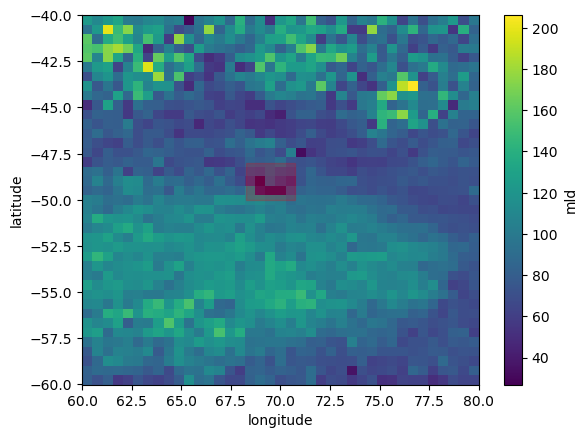

In [14]:
# ds_CL = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/GLORYS_CL_gridded.nc")
### We want to highlight the pixels corresponding to Kerguelen
lon_min = 68.25
lon_max = 70.75
lat_min = -50
lat_max = -48

mask = (
	(ds_CL.longitude >= lon_min) & (ds_CL.longitude <= lon_max)
	& (ds_CL.latitude >= lat_min) & (ds_CL.latitude <= lat_max)
)

ds_CL.mean("time").mld.plot(x="longitude")
ax = plt.gca()

rect = plt.Rectangle(
	(lon_min, lat_min),
	lon_max - lon_min,
	lat_max - lat_min,
	facecolor="red",
	edgecolor="red",
	alpha=0.2,
	linewidth=1,
)
ax.add_patch(rect)

### When satisfied by the region, we mask it in the dataset
ds_CL_masked = ds_CL.where(~mask)

In [15]:
ds_CL = ds_CL_masked.copy()
ds_clim = ds_CL.groupby("time.month").mean("time").mean(["latitude", "longitude"])
ds_anom = ds_CL.groupby("time.month") - ds_clim

In [17]:
### Now that we removed the seasonal cycle we mask kerguelen with 0 instead of nan for the R analysis
ds_CL = ds_anom.where(~mask, other=0) 
ds_clim = ds_clim.where(~mask, other=0)
ds_CL.to_netcdf("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/GLORYS_CL_anom.nc")
ds_clim.to_netcdf("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/GLORYS_CL_clim.nc")

In [12]:
ds_CL = ds_CL.where(ds_CL.time.dt.year < 2024,drop=True)
df_CL = ds_CL.to_dataframe().reset_index()
### We modify the dataset for the R analysis 
df_CL['year'] = df_CL.time.dt.year
df_CL["mth"] = df_CL.time.dt.month
df_CL = df_CL.drop(columns="time")
df_CL = df_CL.rename(columns={"latitude" : "lat","longitude" : "long"})
df_CL = df_CL.fillna("NA")
df_CL = df_CL[["long","lat","mth","year","mld"]]
df_CL = df_CL.sort_values(["year","mth","long","lat"])
df_CL = df_CL.reset_index(drop=True)

In [5]:
### Number of bins for each month = nb_lat_one_month * nb_long_one_month 
nb_lat_one_month=len(np.unique(df_CL.lat))
nb_long_one_month=len(np.unique(df_CL.long))
nb_bins_one_month = nb_lat_one_month * nb_long_one_month
switch = nb_long_one_month*nb_lat_one_month
switch
df_append = df_CL[:switch].copy()
new_df = df_CL.copy()
new_df

### Before this cell look at which month are missing and for which year
# year = 2024
# months = [2,3,4,5,6,7,8,9,10,11,12]
# for i in months: #months that are missing in our df_CL (need to fill them for the R analysis)
#     df_append = df_CL[:switch].copy()
#     df_append["mth"] = i
#     df_append["year"] = year
#     df_append = df_append.reset_index(drop=True).set_index(np.arange(df_CL.index.max()+1,df_CL.index.max()+(switch+1),1))
#     new_df = pd.concat((new_df,df_append))
#     new_df = new_df.sort_values(["year","mth","long","lat"])
#     new_df =new_df.reset_index(drop=True)

new_df

,long,lat,mth,year,mld
0,60.2465,-59.7525,1,2007,NA
1,60.2465,-59.2300,1,2007,NA
2,60.2465,-58.7175,1,2007,NA
3,60.2465,-58.2045,1,2007,NA
4,60.2465,-57.6915,1,2007,NA
...,...,...,...,...,...
310279,79.7435,-42.3080,12,2023,NA
310280,79.7435,-41.7955,12,2023,NA
310281,79.7435,-41.2825,12,2023,NA
310282,79.7435,-40.7695,12,2023,NA


In [13]:
df_CL.to_csv("/home/jupyter-vincent2/vincent/process_profiles/data/R_analysis_2026/raw/GLORYS_CL_masked.txt",sep=" ",index=False)